<a href="https://colab.research.google.com/github/OlajideFemi/Carbon-Footprint/blob/main/Star_Wars_Data_Explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
---
title: "Star Wars Data Explorer"
output:
  flexdashboard::flex_dashboard
runtime: shiny
---

```{r setup, include=FALSE}
library(tidyverse)
library(DT)

# Load the data
startData <- starwars

# Create choices for Group By selector with count of unique values
GBChoices <- as.list(names(startData))
names(GBChoices) <- paste(names(startData), map(startData, ~length(unique(.x))))

# Define the reactive expression
updateData <- reactive({
  # Validate that input$GB exists and has a value
  req(input$GB)

  # Group by selected variable and summarize numeric columns
  startData %>%
    group_by(!!! rlang::syms(input$GB)) %>%
    summarise_if(is.numeric, sum, na.rm = TRUE)
})


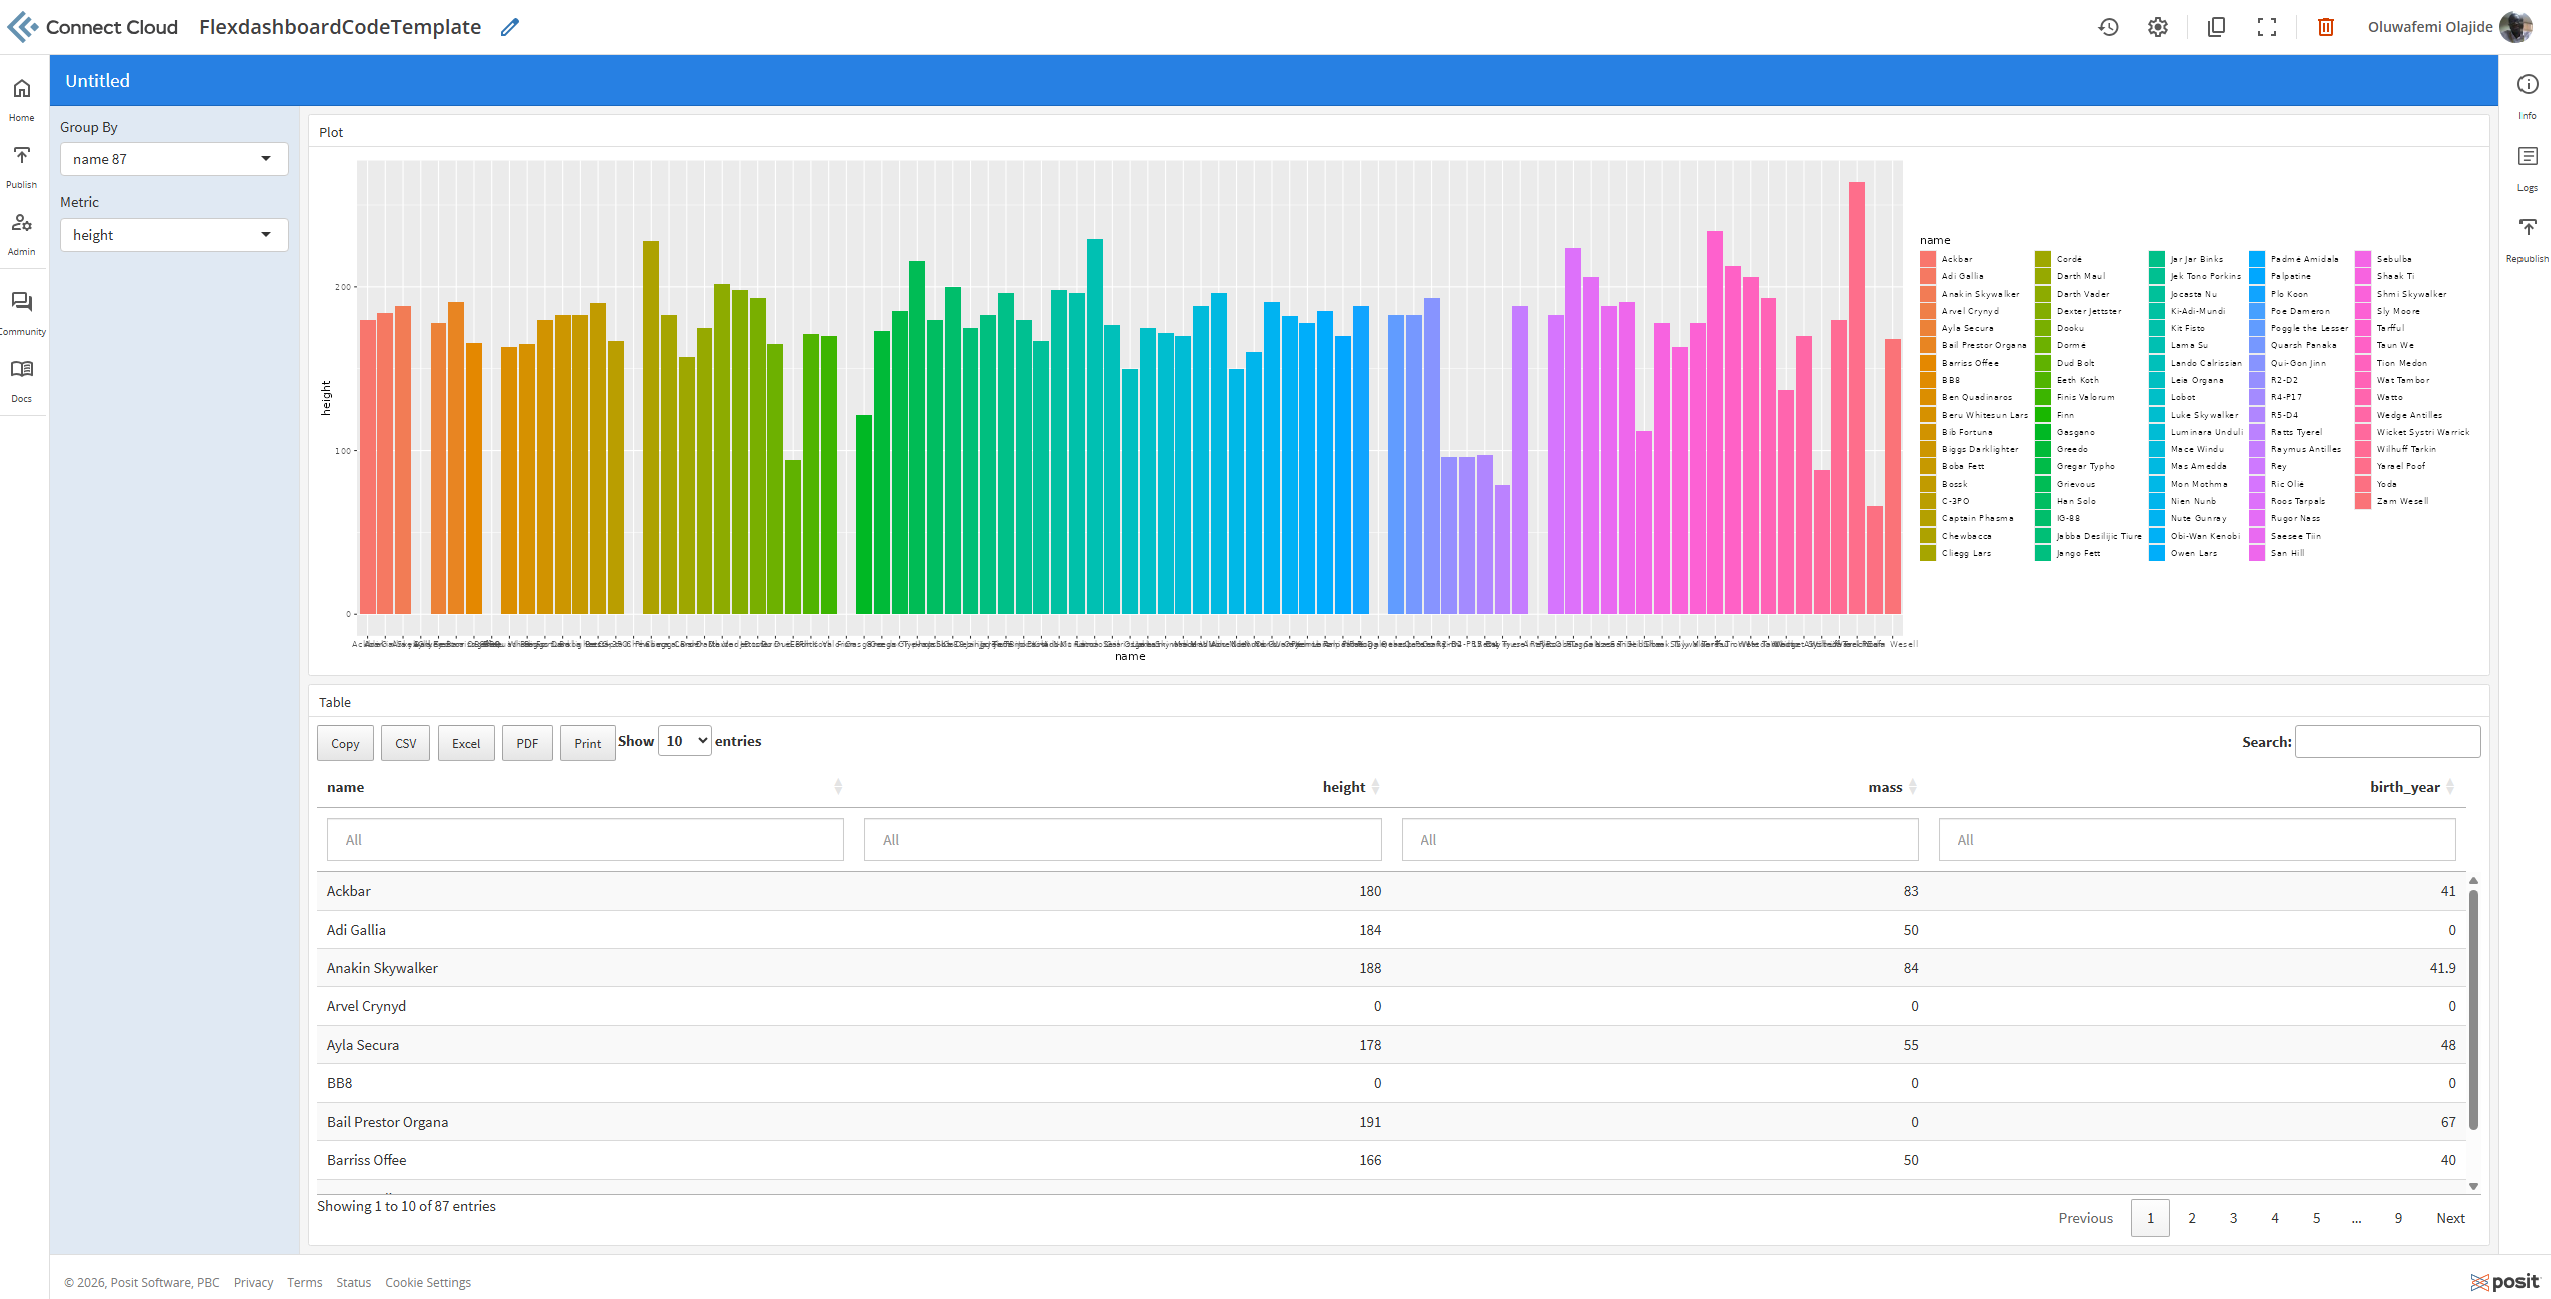